# **Imports**

In [1]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

     |████████████████████████████████| 1.5 MB 4.9 MB/s 
     |████████████████████████████████| 9.5 MB 38.6 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2
  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-6h6ge7lt
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-6h6ge7lt
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.
  Created wheel for sklearn-contrib-py-earth: filename=sklearn_contrib_py_earth-0.1.0+16.g400f84d-cp37-cp37m-linux_x86_64.whl size=3997326 sha256=2a17c02e6d939c827d80c27b3bf8656afd2b5286acc9cb9e3898929a2cef6180
  Stored in directory: /tmp/pip-ephem-wheel-cache-lci5sy5l/wheels/79/d7/aa/1e418a9aea84424ef2ce2697ae7c

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [3]:
!gdown --id 1rZzXVgHlHUWBAZQELzusrUjCCl4CJb1Q

Downloading...
From: https://drive.google.com/uc?id=1rZzXVgHlHUWBAZQELzusrUjCCl4CJb1Q
To: /content/MARUTI.NS.csv
100% 139k/139k [00:00<00:00, 76.1MB/s]


In [4]:
stock_name="MARUTI"

In [5]:
df_stock = pd.read_csv('MARUTI.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,4621.000000,4668.000000,4602.350098,4638.500000,243597.0,4,1,1,7791.299805,65.649902
2016-01-04,4635.000000,4657.000000,4571.750000,4580.649902,405501.0,0,4,1,7784.649902,85.250000
2016-01-05,4599.950195,4600.750000,4557.250000,4566.950195,509285.0,1,5,1,7741.000000,43.500000
2016-01-06,4592.000000,4593.000000,4468.000000,4480.799805,593742.0,2,6,1,7568.299805,125.000000
2016-01-07,4449.700195,4449.700195,4251.850098,4267.899902,1200069.0,3,7,1,7601.350098,197.850098


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [6]:
df_stock['Close'].head()

Date
2016-01-01    4638.500000
2016-01-04    4580.649902
2016-01-05    4566.950195
2016-01-06    4480.799805
2016-01-07    4267.899902
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - MARUTI')

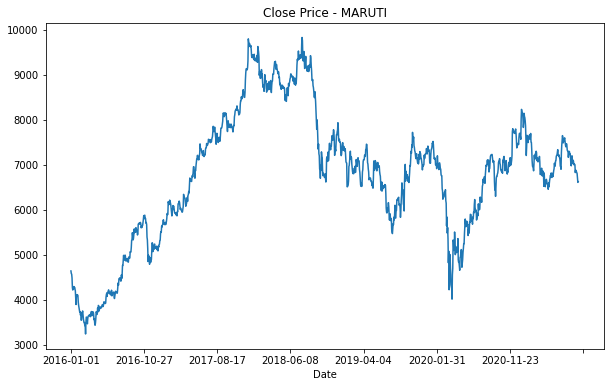

In [7]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

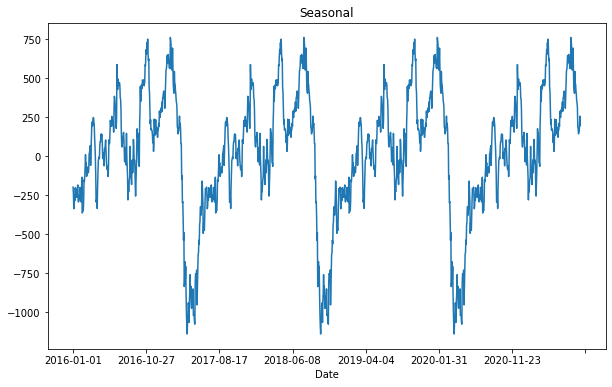

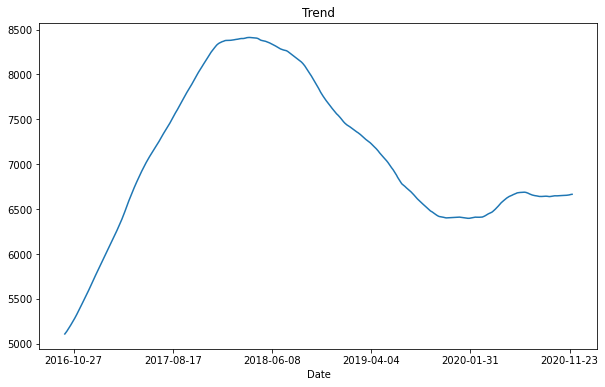

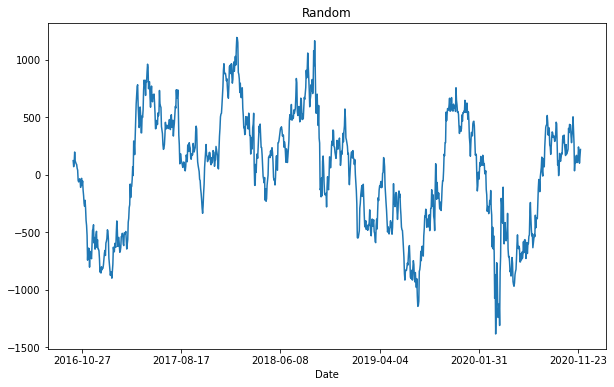

In [8]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [9]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.3565930067468581
0.0
Test Statistic                  -36.943419
p-value                           0.000000
#lags used                        0.000000
number of observations used    1386.000000
critical value (1%)              -3.435077
critical value (5%)              -2.863628
critical value (10%)             -2.567881
dtype: float64
Differencing Value :  2


##*ACF*

In [10]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.00000000e+00  7.06275223e-03  7.30901346e-03 -2.99411443e-04
 -7.58990075e-03 -1.62309674e-02 -2.67003129e-02  3.85982592e-02
  9.05682761e-03 -2.49092412e-03  1.94059618e-02 -5.31397983e-02
  9.66034183e-03  1.19001944e-03  1.67694724e-05  2.13117207e-02
 -6.97689458e-03  1.84280805e-02  7.15043019e-03  3.60014430e-02
  2.40501969e-02]


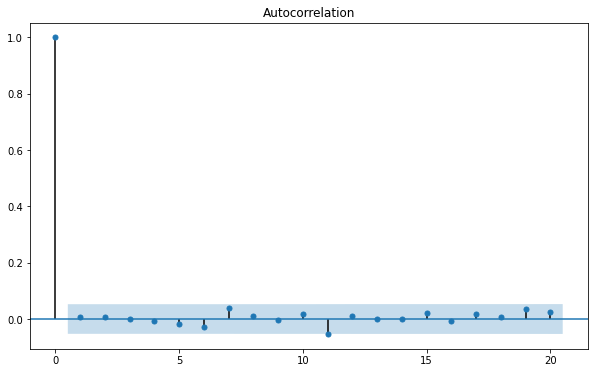

In [11]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [12]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.00000000e+00  7.06784801e-03  7.26997668e-03 -4.02842452e-04
 -7.66092187e-03 -1.61799983e-02 -2.64899858e-02  3.94280754e-02
  8.90704229e-03 -3.48831027e-03  1.88436702e-02 -5.42528137e-02
  1.10272747e-02  4.25161288e-03 -1.10969782e-03  2.07842114e-02
 -7.99942509e-03  1.45644792e-02  1.16619786e-02  3.69058629e-02
  2.34348619e-02]


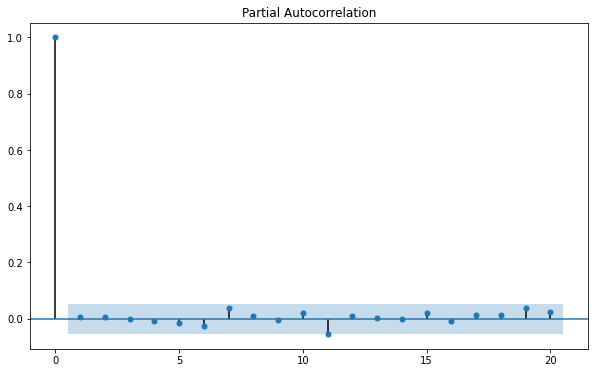

In [13]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

##*Test and Train Split*

In [14]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [15]:
df_stock_train.tail()

Date
2021-07-26    7235.799805
2021-07-27    7240.250000
2021-07-28    7165.049805
2021-07-29    6993.500000
2021-07-30    6977.700195
Name: Close, dtype: float64

In [16]:
df_stock_test.head()

Date
2021-08-02    7076.950195
2021-08-03    7199.399902
2021-08-04    7102.899902
2021-08-05    7027.549805
2021-08-06    7100.799805
Name: Close, dtype: float64

##*Model Fitting*

In [17]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [18]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(0, 1, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=False)

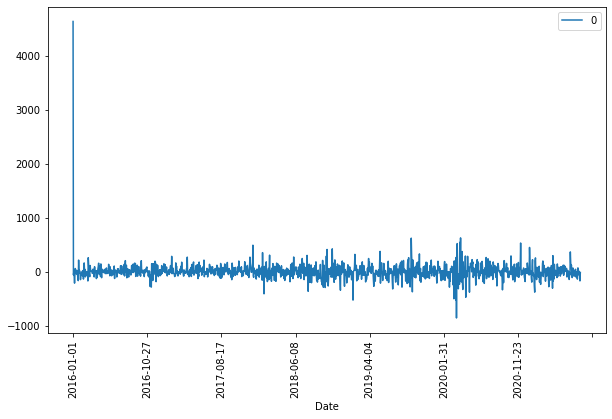

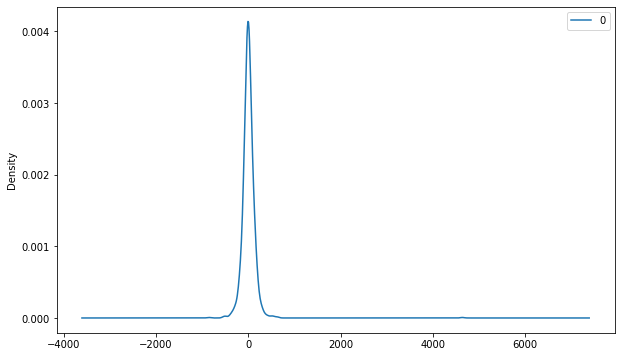

                 0
count  1369.000000
mean      5.070793
std     173.153859
min    -858.161911
25%     -59.576835
50%      -0.549982
75%      60.851503
max    4638.500000


In [19]:
model = ARIMA(df_stock_train, order=(1,1,1))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [20]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 1.0964955504357796


([], <a list of 0 Text major ticklabel objects>)

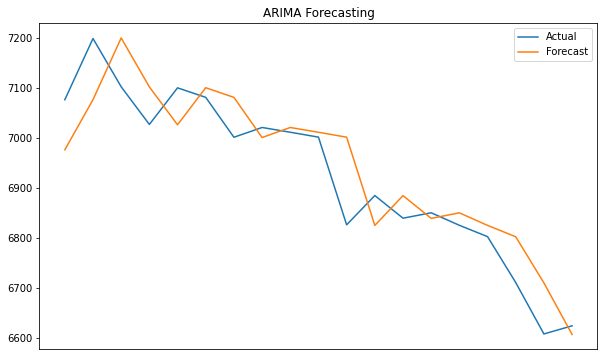

In [21]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [22]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [23]:
predictions

[6976.832169649763,
 7077.1854715211075,
 7200.518009356912,
 7102.669964670131,
 7026.877033572829,
 7101.027170625881,
 7081.721747769515,
 7001.421260833041,
 7021.46690727016,
 7011.917359474065,
 7002.10046061324,
 6825.640232602331,
 6885.230095429529,
 6839.737848054854]

#**MARS - Multivariate Adaptive Regression Splines**

In [24]:
from pyearth import Earth

In [25]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [26]:
df_stock_mars_train.shape

(1369, 5)

In [27]:
df_stock_mars_test.shape

(19, 5)

In [28]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,4621.000000,4668.000000,4602.350098,4638.500000,243597.0
2016-01-04,4635.000000,4657.000000,4571.750000,4580.649902,405501.0
2016-01-05,4599.950195,4600.750000,4557.250000,4566.950195,509285.0
2016-01-06,4592.000000,4593.000000,4468.000000,4480.799805,593742.0
2016-01-07,4449.700195,4449.700195,4251.850098,4267.899902,1200069.0


In [29]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,7100.000000,7107.450195,7031.000000,7076.950195,433760.0
2021-08-03,7124.950195,7221.000000,7086.100098,7199.399902,470570.0
2021-08-04,7220.000000,7248.600098,7003.500000,7102.899902,484122.0
2021-08-05,7072.000000,7079.950195,7006.000000,7027.549805,495133.0
2021-08-06,7054.799805,7168.500000,7042.549805,7100.799805,517575.0
2021-08-09,7135.000000,7165.000000,7038.000000,7081.750000,264983.0
2021-08-10,7045.200195,7104.899902,6995.000000,7001.950195,356726.0
2021-08-11,7002.000000,7095.000000,6925.149902,7021.500000,414311.0
2021-08-12,7022.000000,7084.799805,6985.000000,7012.000000,330283.0


In [30]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [31]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [32]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 34.55
RMSE/Mean 0.5


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

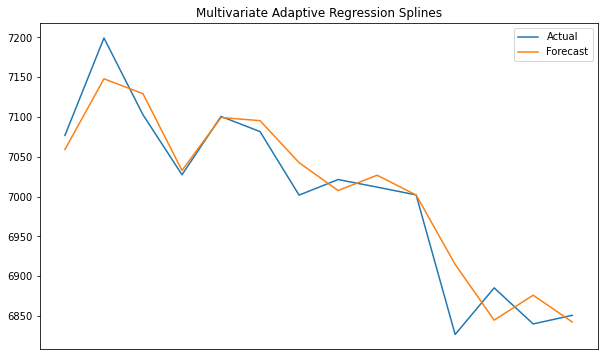

In [33]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [34]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [35]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [36]:
df_stock_var_train.shape

(1369, 4)

In [37]:
df_stock_var_test.shape

(14, 4)

In [38]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

In [39]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

##*Granger Causality Test*

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0000,0.0000,0.0000,0.0
High_y,0.0000,1.0000,0.0000,0.0
Low_y,0.0000,0.0000,1.0000,0.0
Close_y,0.0061,0.0067,0.0271,1.0


##*Cointegration Test*

In [41]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  496.22    > 40.1749   =>   True
High   ::  256.15    > 24.2761   =>   True
Low    ::  66.17     > 12.3212   =>   True
Close  ::  0.03      > 4.1296    =>   False


##*ADF Test*

In [42]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [43]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.9056
 No. Lags Chosen       = 5
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.3294. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.867
 No. Lags Chosen       = 4
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.3477. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root

##*ADF Test on first order differencing*

In [44]:
df_differenced = df_stock_var_train.diff().dropna()

In [45]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -17.6113
 No. Lags Chosen       = 4
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -18.8938
 No. Lags Chosen       = 3
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05

##*Selecting the number of lags*

In [46]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,35.53,35.54,2.690e+15,35.53
1,33.81,33.89,4.832e+14,33.84
2,33.24,33.38,2.726e+14,33.29
3,33.02,33.22,2.179e+14,33.09
4,32.92,33.18,1.976e+14,33.02
5,32.83,33.15*,1.811e+14,32.95
6,32.80,33.19,1.756e+14,32.94
7,32.75,33.20,1.676e+14,32.92*
8,32.74,33.25,1.653e+14,32.93
9,32.72,33.30,1.629e+14,32.94


##*Fitting the model*

In [47]:
model_fitted = model.fit(x.aic)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Sep, 2021
Time:                     15:54:13
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    33.7633
Nobs:                     1351.00    HQIC:                   33.0977
Log likelihood:          -29480.3    FPE:                1.58941e+14
AIC:                      32.6992    Det(Omega_mle):     1.30227e+14
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.206244         1.389706            0.148           0.882
L1.Open          -1.043083         0.038232          -27.283           0.000
L1.High           0.069888         0.035987            1.942           0.052


##*Durbin Watson Test*

In [48]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 2.0
High : 2.0
Low : 2.0
Close : 2.0


##*Getting the Forecast*

In [49]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

17


array([[ -72.        ,  -76.95019531,  -53.80029297,  -65.55029297],
       [ -73.        ,  -83.        ,  -48.64990234,  -48.19970703],
       [ -74.        ,  -50.10009766,  -41.60009766,   24.5       ],
       [ 119.        ,  141.89990234,  107.64990234,   44.39990234],
       [  20.        ,  -60.59960938,  -47.04980469,  -39.75      ],
       [ -84.        ,  -80.20019531,  -94.        , -103.60009766],
       [ -79.        ,  -91.        ,  -42.        ,  -19.75      ],
       [ -24.        ,  -25.        ,    4.79980469,   -3.45019531],
       [ -81.29980469,  -36.        , -121.69970703, -138.        ],
       [ -71.70019531,  -32.        ,   -6.64990234,   67.15039062],
       [ 122.        ,   60.        ,  101.84960938,   66.84960938],
       [  -2.        ,   50.        ,   30.70019531,   -5.69970703],
       [   7.        ,  -15.        ,  -97.        ,  -58.05029297],
       [ -65.70019531,  -40.        ,  -19.14990234,    4.45019531],
       [  38.70019531,   -8.      

In [50]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,-12.981159,-30.439720,-59.952048,-13.961150
2021-08-03,-24.453072,-26.881141,-40.114256,-21.881800
2021-08-04,-4.302574,16.021949,1.228217,10.420148
2021-08-05,6.976146,-18.202839,8.446384,-13.049146
2021-08-06,-1.807137,13.339745,16.019484,32.127833
2021-08-09,23.043775,11.180705,13.531273,7.627515
2021-08-10,15.722027,16.271650,1.801805,-4.114306
2021-08-11,-5.545412,-23.158670,-5.694341,-22.449582
2021-08-12,-32.506028,-34.447879,-25.361767,-14.427307


##*Inverting forecast back to original scale*

In [51]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [52]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,6987.018841,7064.560280,6904.947854,6963.739046
2021-08-03,6962.565769,7037.679140,6864.833598,6941.857245
2021-08-04,6958.263195,7053.701088,6866.061815,6952.277394
2021-08-05,6965.239341,7035.498249,6874.508199,6939.228248
2021-08-06,6963.432204,7048.837994,6890.527683,6971.356080
2021-08-09,6986.475978,7060.018699,6904.058956,6978.983595
2021-08-10,7002.198006,7076.290349,6905.860761,6974.869289
2021-08-11,6996.652594,7053.131679,6900.166420,6952.419707
2021-08-12,6964.146566,7018.683800,6874.804653,6937.992401


##*Plotting Forecast vs Actual*

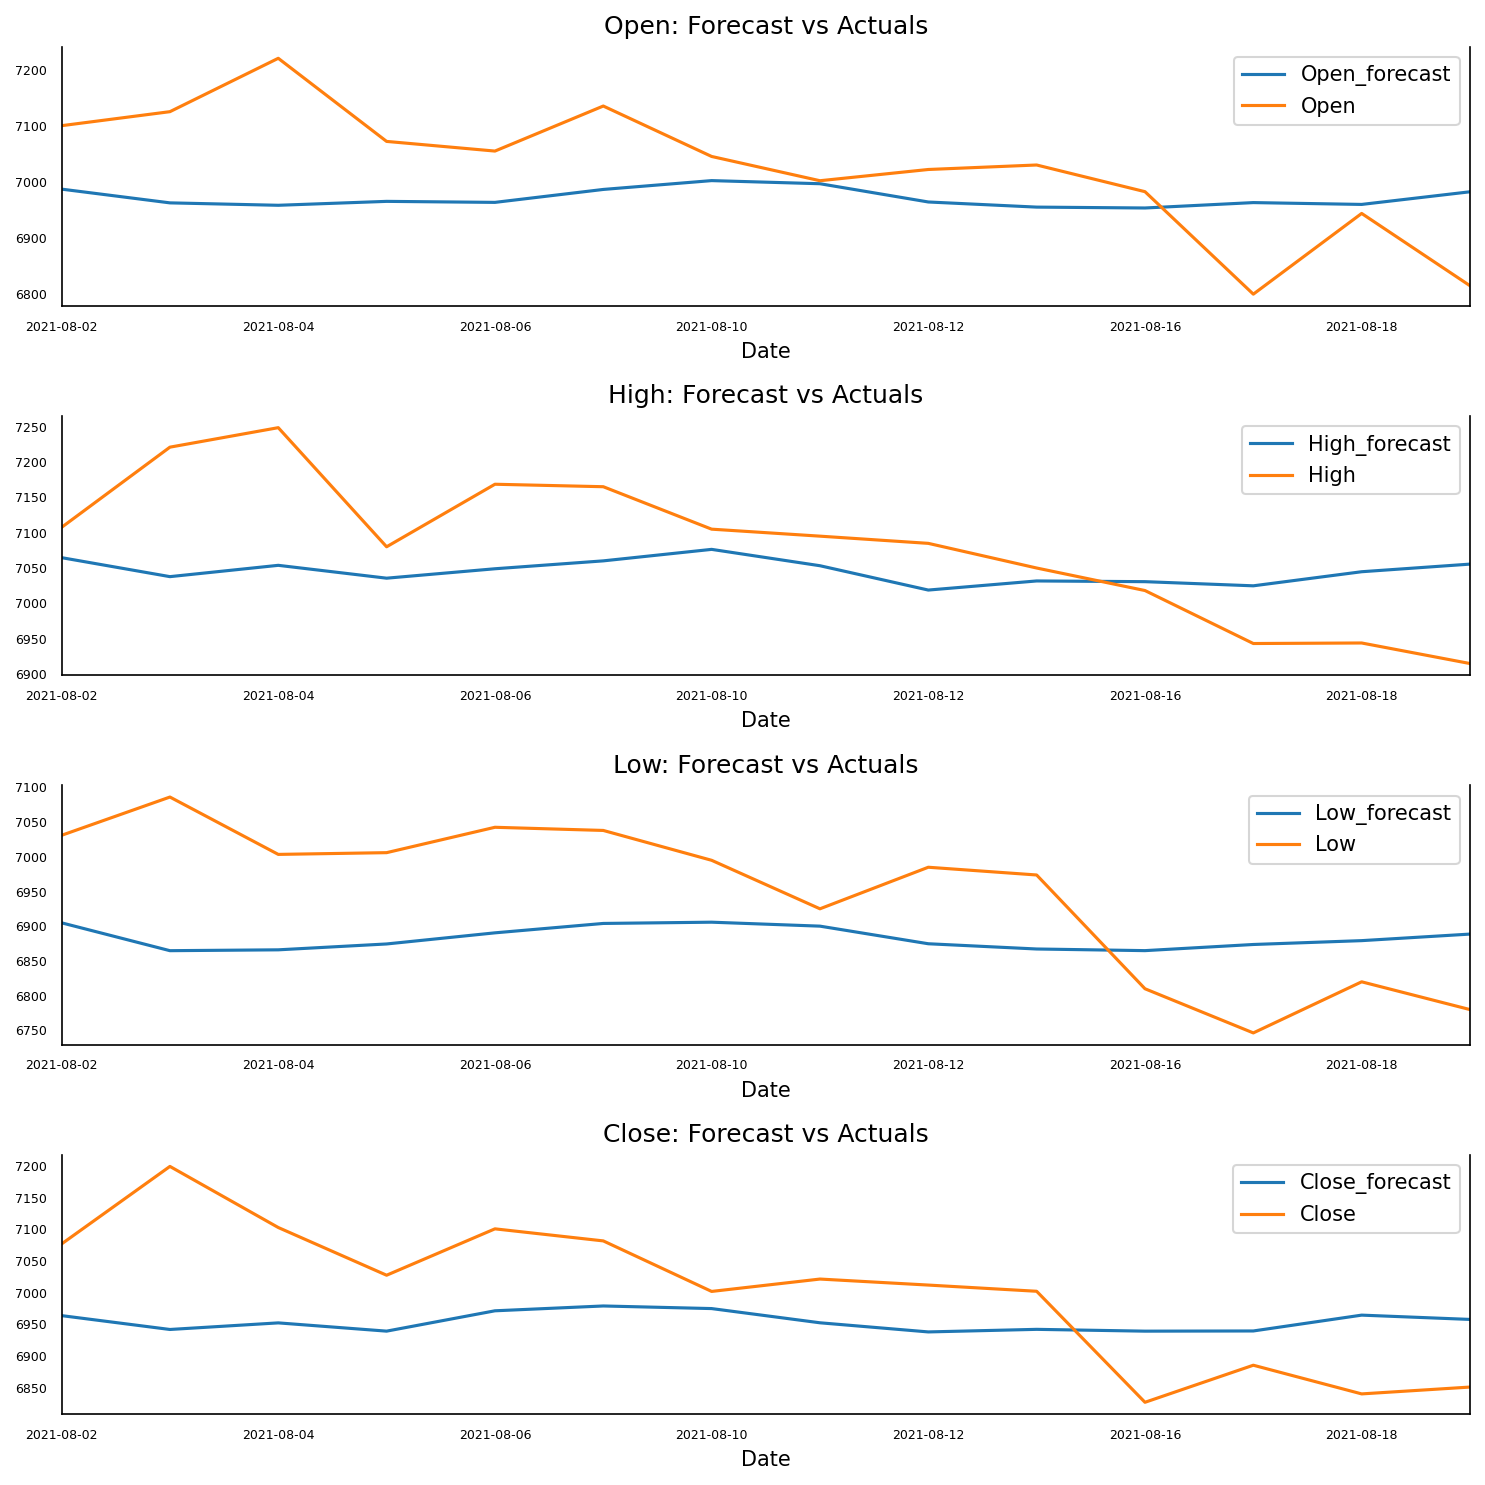

In [53]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [54]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  124.2041
rmse_mean :  1.7681

Forecast Accuracy of High
rmse :  101.7176
rmse_mean :  1.4363

Forecast Accuracy of Low
rmse :  122.1012
rmse_mean :  1.7579

Forecast Accuracy of Close
rmse :  117.7134
rmse_mean :  1.6811


#**Linear Regression**

In [55]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [56]:
from sklearn.preprocessing import MinMaxScaler

In [57]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [58]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.209916,0.187923,0.215731,4638.500000,0.040563,4,1,1,0.091661,0.026600
2016-01-04,0.211985,0.186247,0.211046,4580.649902,0.073973,0,4,1,0.090919,0.042568
2016-01-05,0.206804,0.177674,0.208826,4566.950195,0.095390,1,5,1,0.086044,0.008554
2016-01-06,0.205629,0.176493,0.195162,4480.799805,0.112818,2,6,1,0.066755,0.074952
2016-01-07,0.184595,0.154653,0.162070,4267.899902,0.237939,3,7,1,0.070447,0.134303


In [59]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,0.576355,0.559709,0.587553,7076.950195,0.079805,0,2,8,1.023069,0.035399
2021-08-03,0.580043,0.577014,0.595989,7199.399902,0.087401,1,3,8,1.037370,0.083018
2021-08-04,0.594093,0.581221,0.583343,7102.899902,0.090197,2,4,8,1.041369,0.172797
2021-08-05,0.572216,0.555517,0.583726,7027.549805,0.092469,3,5,8,1.035070,0.033362
2021-08-06,0.569674,0.569013,0.589321,7100.799805,0.097100,4,6,8,1.037309,0.075726


##*Checking for multicollinearity*

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [61]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [62]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [63]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [64]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [65]:
print(model.summary2())

                  Results: Ordinary least squares
Model:               OLS              Adj. R-squared:     0.994     
Dependent Variable:  Close            AIC:                16822.2860
Date:                2021-09-15 15:54 BIC:                16916.2790
No. Observations:    1369             Log-Likelihood:     -8393.1   
Df Model:            17               F-statistic:        1.398e+04 
Df Residuals:        1351             Prob (F-statistic): 0.00      
R-squared:           0.994            Scale:              12545.    
--------------------------------------------------------------------
                Coef.   Std.Err.    t     P>|t|    [0.025    0.975] 
--------------------------------------------------------------------
Open          6731.5160  14.6557 459.3106 0.0000 6702.7656 6760.2664
Volume         108.9726  28.6308   3.8061 0.0001   52.8069  165.1383
Day of Week_0 2249.9634   9.4917 237.0463 0.0000 2231.3434 2268.5834
Day of Week_1 2263.9590   9.5863 236.1665 0.0000 2245

In [66]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


Open
Volume
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Month_1
Month_2
Month_3
Month_4
Month_5
Month_6
Month_7
Month_8
Month_9
Month_10
Month_11
Month_12


In [67]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
0.9760108946259533
